<a href="https://colab.research.google.com/github/Goyallgithub/yosicon2026TrueAI/blob/main/PPCM_Cuproptosis_Transformer_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transformer-Based Risk Stratification in Peripartum Cardiomyopathy
## Machine Learning for Identifying High-Risk Patients Using Cuproptosis Gene Signatures

**Dataset:** GSE141910 (Non-Failing Donors / Control, Dilated Cardiomyopathy, Peripartum Cardiomyopathy)

This notebook provides a complete, reproducible analysis pipeline for transcriptomic data focusing on
cuproptosis-associated gene signatures—particularly **DLAT**, **LIPT1**, and **PDHA1**—which have been
implicated in mitochondrial copper-dependent cell death pathways relevant to PPCM pathophysiology.

---

### Expected Input Format (`GSE141910_data.csv`)

| Format | Description |
|--------|-------------|
| **Preferred** | Rows = samples, columns = gene symbols + one metadata column (`Group`, `Condition`, or `Label`) |
| **Alternative** | Rows = genes, columns = samples + metadata row/column (auto-transposed) |

Accepted group labels (case-insensitive): `Control`, `NF`, `Non-Failing`, `DCM`, `PPCM`.

All publication figures are saved as **300 DPI PDF** files in the `figures/` directory.

## 0. Environment Setup (Google Colab Compatible)

In [18]:
# Install dependencies (safe to re-run on Colab)
!pip install -q imbalanced-learn statsmodels torch

In [19]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from scipy import stats
from scipy.stats import spearmanr

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_curve, auc, roc_auc_score
)
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Publication-quality matplotlib style ──────────────────────────────────────
mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.titlesize': 15,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

PALETTE = {'Control': '#4C72B0', 'DCM': '#DD8452', 'PPCM': '#C44E52'}
GROUP_ORDER = ['Control', 'DCM', 'PPCM']
CUPROPTOSIS_GENES = ['DLAT', 'LIPT1', 'PDHA1', 'FDX1', 'LIAS', 'DLD', 'SLC31A1']
HIGHLIGHT_GENES = ['DLAT', 'LIPT1', 'PDHA1']
FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name: str):
    """Save current figure as 300 DPI PDF."""
    path = os.path.join(FIG_DIR, f'{name}.pdf')
    plt.savefig(path, format='pdf', dpi=300, bbox_inches='tight')
    print(f'  Saved → {path}')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch device: {device}')

PyTorch device: cpu


## 1. Data Loading and Preprocessing

**Rationale:** We load the GSE141910 transcriptomic matrix and separate gene-expression features
from clinical group labels. Cuproptosis genes are isolated because copper-dependent regulated cell
death (cuproptosis) involves mitochondrial enzymes whose dysregulation may stratify PPCM risk.
StandardScaler normalizes expression magnitudes across genes, and SMOTE synthetically oversamples
the minority PPCM class to mitigate severe class imbalance during supervised learning.

In [20]:
# ── Upload / locate dataset ───────────────────────────────────────────────────
DATA_FILE = 'GSE141910_data.csv'

if not os.path.exists(DATA_FILE):
    try:
        from google.colab import files
        print('Please upload GSE141910_data.csv:')
        uploaded = files.upload()
        DATA_FILE = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            f'{DATA_FILE} not found. Place the CSV in the working directory or run on Google Colab.'
        )

raw_df = pd.read_csv(DATA_FILE, index_col=0)
print(f'Loaded: {raw_df.shape[0]} rows × {raw_df.shape[1]} columns')
raw_df.head(3)

Loaded: 338 rows × 41385 columns


,7SK,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A2MP1,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11AP1,ZYG11B,ZYX,ZZEF1,ZZZ3,Group
SampleID,,,,,,,,,,,,,,,,,,,,,
C00039,3.459432,2.584963,4.754888,0.0,14.533330,7.761551,2.0,0.0,0.0,5.459432,...,7.417853,8.864186,9.707359,1.584963,0.0,11.731319,10.096715,10.622052,10.232421,Control
C00055,3.321928,2.000000,5.781360,0.0,15.783612,8.149747,3.0,0.0,0.0,5.392317,...,7.900867,9.262095,9.566054,1.000000,0.0,12.692398,9.984418,11.221587,10.837628,Control
C00074,3.584963,0.000000,4.954196,0.0,13.786372,4.392317,0.0,0.0,0.0,3.169925,...,6.189825,7.531381,8.921841,0.000000,0.0,10.027906,11.443980,9.455327,9.601771,Control


In [21]:
# ── Detect orientation and extract labels ─────────────────────────────────────
LABEL_CANDIDATES = ['group', 'condition', 'label', 'class', 'disease', 'phenotype', 'status']

def normalize_label(val):
    """Map heterogeneous label strings to Control / DCM / PPCM."""
    v = str(val).strip().lower()
    if v in ('control', 'nf', 'non-failing', 'nonfailing', 'non failing', 'normal', 'donor'):
        return 'Control'
    if v in ('dcm', 'dilated cardiomyopathy', 'dilated_cm'):
        return 'DCM'
    if v in ('ppcm', 'peripartum cardiomyopathy', 'peripartum_cm'):
        return 'PPCM'
    return str(val).strip()

def find_label_column(df):
    for col in df.columns:
        if col.lower() in LABEL_CANDIDATES:
            return col
    # Check if labels are in the index
    if df.index.name and df.index.name.lower() in LABEL_CANDIDATES:
        return '__index__'
    # Heuristic: object column with ≤5 unique values
    for col in df.columns:
        if df[col].dtype == object and df[col].nunique() <= 5:
            return col
    return None

def is_gene_index(idx):
    """Heuristic: gene symbols are short uppercase strings."""
    sample = [str(x) for x in list(idx)[:20]]
    upper_frac = sum(1 for s in sample if s.isupper() and 2 <= len(s) <= 15) / max(len(sample), 1)
    return upper_frac > 0.5

label_col = find_label_column(raw_df)

if label_col is None and is_gene_index(raw_df.index):
    # Genes-as-rows format: transpose so samples are rows
    print('Detected genes-as-rows format → transposing.')
    raw_df = raw_df.T
    label_col = find_label_column(raw_df)

if label_col is None:
    raise ValueError(
        'Could not identify a group label column. Add a column named Group/Condition/Label '
        'with values Control, DCM, or PPCM.'
    )

if label_col == '__index__':
    labels = raw_df.index.map(normalize_label)
    expr_df = raw_df.copy()
else:
    labels = raw_df[label_col].map(normalize_label)
    expr_df = raw_df.drop(columns=[label_col])

# Coerce expression values to numeric
expr_df = expr_df.apply(pd.to_numeric, errors='coerce')
expr_df = expr_df.dropna(axis=1, how='all').dropna(axis=0, how='all')
labels = labels.loc[expr_df.index]

# Standardize gene column names (uppercase)
expr_df.columns = expr_df.columns.str.upper().str.strip()

print('Class distribution:')
print(labels.value_counts().reindex(GROUP_ORDER).dropna())
print(f'\nExpression matrix: {expr_df.shape[0]} samples × {expr_df.shape[1]} genes')

Class distribution:
Group
Control    166
DCM        166
PPCM         6
Name: count, dtype: int64

Expression matrix: 338 samples × 41384 genes


In [22]:
# ── Filter cuproptosis genes ──────────────────────────────────────────────────
available_cupro = [g for g in CUPROPTOSIS_GENES if g in expr_df.columns]
missing = [g for g in CUPROPTOSIS_GENES if g not in expr_df.columns]

if missing:
    print(f'Warning – genes not found in dataset: {missing}')
if len(available_cupro) < 3:
    raise ValueError(
        f'Fewer than 3 cuproptosis genes found. Available: {available_cupro}. '
        'Check gene symbol naming in your CSV.'
    )

print(f'Cuproptosis genes retained: {available_cupro}')

X_all = expr_df.values.astype(np.float64)          # all genes (for PCA / volcano)
genes_all = expr_df.columns.tolist()
X_cupro = expr_df[available_cupro].values.astype(np.float64)
y_str = labels.values

# Encode labels
le = LabelEncoder()
le.fit(GROUP_ORDER)
y = le.transform(y_str)

# StandardScaler on cuproptosis features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cupro)
X_scaled_df = pd.DataFrame(X_scaled, columns=available_cupro, index=expr_df.index)
X_scaled_df['Group'] = y_str

# SMOTE for class imbalance
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=min(5, min(np.bincount(y)) - 1))
X_bal, y_bal = smote.fit_resample(X_scaled, y)

print(f'\nAfter SMOTE: {X_bal.shape[0]} samples (was {X_scaled.shape[0]})')
print('Balanced class distribution:', dict(zip(le.classes_, np.bincount(y_bal))))

Cuproptosis genes retained: ['DLAT', 'LIPT1', 'PDHA1', 'FDX1', 'LIAS', 'DLD', 'SLC31A1']

After SMOTE: 498 samples (was 338)
Balanced class distribution: {np.str_('Control'): np.int64(166), np.str_('DCM'): np.int64(166), np.str_('PPCM'): np.int64(166)}


## 2. Publication-Quality Exploratory Data Analysis (EDA)

We generate eight manuscript-ready figures characterizing global transcriptomic structure,
differential expression, cuproptosis gene dynamics, and inter-gene co-expression patterns.

### Figure 1 — Principal Component Analysis (PCA)

PCA projects the high-dimensional gene expression space onto two orthogonal components,
revealing whether PPCM samples segregate from Control and DCM cohorts in transcriptomic space.

  Saved → figures/Figure1_PCA.pdf


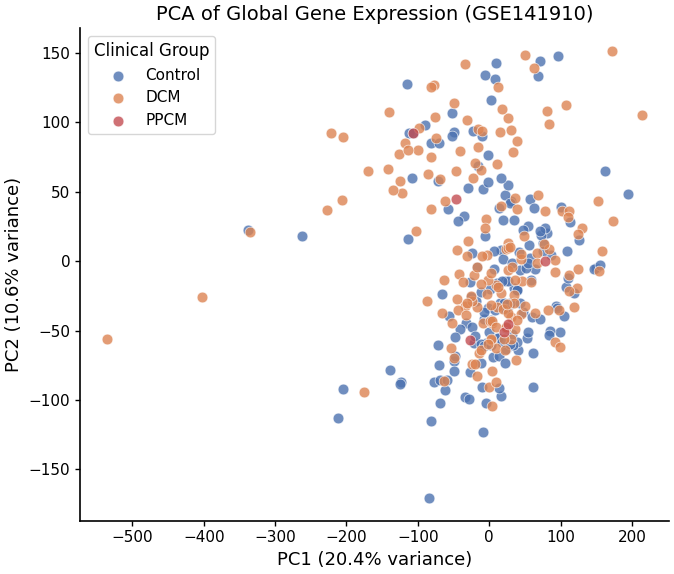

In [23]:
# PCA on all genes (global expression landscape)
X_pca_input = StandardScaler().fit_transform(X_all)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_pca_input)
pca_df = pd.DataFrame(pca_coords, columns=['PC1', 'PC2'], index=expr_df.index)
pca_df['Group'] = y_str

fig, ax = plt.subplots(figsize=(7, 6))
for grp in GROUP_ORDER:
    mask = pca_df['Group'] == grp
    if mask.any():
        ax.scatter(
            pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
            c=PALETTE[grp], label=grp, s=60, alpha=0.8,
            edgecolors='white', linewidths=0.5
        )

var1, var2 = pca.explained_variance_ratio_[:2] * 100
ax.set_xlabel(f'PC1 ({var1:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var2:.1f}% variance)')
ax.set_title('PCA of Global Gene Expression (GSE141910)')
ax.legend(title='Clinical Group', frameon=True, edgecolor='0.8')
plt.tight_layout()
save_fig('Figure1_PCA')
plt.show()

### Figure 2 — Volcano Plot (PPCM vs. Control)

Differential expression is assessed via two-sample Welch's *t*-test. Genes with |log₂FC| > 1 and
FDR-adjusted *p* < 0.05 are considered significant. DLAT, LIPT1, and PDHA1 are highlighted.

  Saved → figures/Figure2_Volcano.pdf


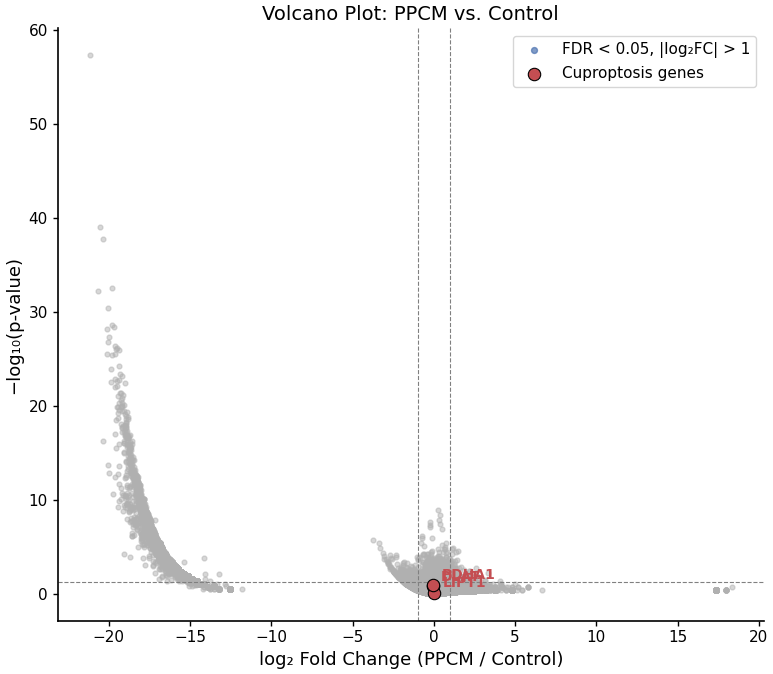

 gene    log2FC   pvalue  padj
 DLAT -0.068621 0.163287   NaN
LIPT1  0.014432 0.734959   NaN
PDHA1 -0.044643 0.103601   NaN


In [24]:
from statsmodels.stats.multitest import multipletests

ppcm_mask = np.array([g == 'PPCM' for g in y_str])
ctrl_mask = np.array([g == 'Control' for g in y_str])

de_results = []
for i, gene in enumerate(genes_all):
    ppcm_vals = X_all[ppcm_mask, i]
    ctrl_vals = X_all[ctrl_mask, i]
    if len(ppcm_vals) < 2 or len(ctrl_vals) < 2:
        continue
    log2fc = np.log2((np.mean(ppcm_vals) + 1e-6) / (np.mean(ctrl_vals) + 1e-6))
    _, pval = stats.ttest_ind(ppcm_vals, ctrl_vals, equal_var=False)
    de_results.append({'gene': gene, 'log2FC': log2fc, 'pvalue': pval})

de_df = pd.DataFrame(de_results)
_, de_df['padj'], _, _ = multipletests(de_df['pvalue'], method='fdr_bh')
de_df['neg_log10_p'] = -np.log10(de_df['pvalue'].clip(lower=1e-300))
de_df['significant'] = (de_df['padj'] < 0.05) & (de_df['log2FC'].abs() > 1)

fig, ax = plt.subplots(figsize=(8, 7))
nonsig = de_df[~de_df['significant']]
sig = de_df[de_df['significant']]

ax.scatter(nonsig['log2FC'], nonsig['neg_log10_p'], c='#B0B0B0', s=12, alpha=0.5, rasterized=True)
ax.scatter(sig['log2FC'], sig['neg_log10_p'], c='#4C72B0', s=18, alpha=0.7, rasterized=True, label='FDR < 0.05, |log₂FC| > 1')

# Highlight cuproptosis genes of interest
highlight = de_df[de_df['gene'].isin(HIGHLIGHT_GENES)]
ax.scatter(highlight['log2FC'], highlight['neg_log10_p'], c='#C44E52', s=80,
           edgecolors='black', linewidths=0.8, zorder=5, label='Cuproptosis genes')
for _, row in highlight.iterrows():
    ax.annotate(row['gene'], (row['log2FC'], row['neg_log10_p']),
                textcoords='offset points', xytext=(6, 4), fontsize=10, fontweight='bold', color='#C44E52')

ax.axhline(-np.log10(0.05), ls='--', color='0.5', lw=0.8)
ax.axvline(-1, ls='--', color='0.5', lw=0.8)
ax.axvline(1, ls='--', color='0.5', lw=0.8)
ax.set_xlabel('log₂ Fold Change (PPCM / Control)')
ax.set_ylabel('−log₁₀(p-value)')
ax.set_title('Volcano Plot: PPCM vs. Control')
ax.legend(loc='upper right', frameon=True, edgecolor='0.8')
plt.tight_layout()
save_fig('Figure2_Volcano')
plt.show()

# Report highlight gene statistics
print(de_df[de_df['gene'].isin(HIGHLIGHT_GENES)][['gene', 'log2FC', 'pvalue', 'padj']].to_string(index=False))

### Figure 3 — Violin Plots with Statistical Annotations

Normalized expression of DLAT, LIPT1, and PDHA1 is compared across clinical groups.
Pairwise Welch's *t*-tests with Bonferroni correction determine significance levels
(\* *p*<0.05, \*\* *p*<0.01, \*\*\* *p*<0.001).

  Saved → figures/Figure3_Violin_Boxplots.pdf


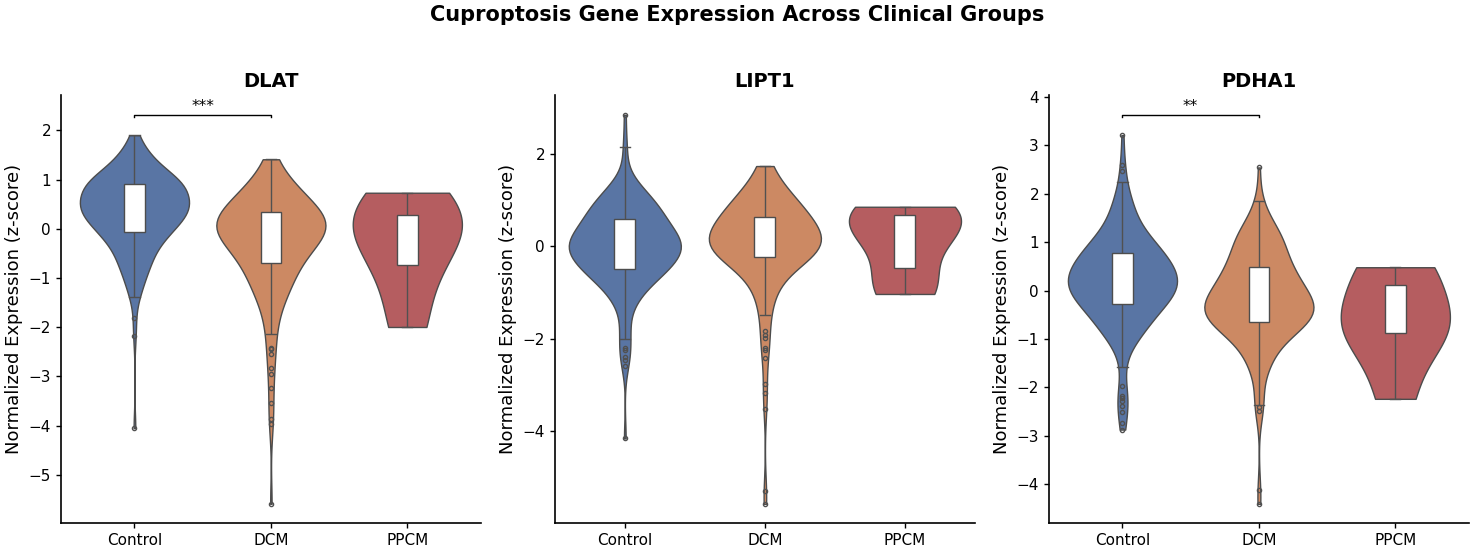

In [25]:
def p_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def add_significance_bracket(ax, x1, x2, y, p, h=0.04):
    stars = p_to_stars(p)
    if stars == 'ns':
        return
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.0, color='black')
    ax.text((x1 + x2) / 2, y + h + 0.01, stars, ha='center', va='bottom', fontsize=11)

plot_genes = [g for g in HIGHLIGHT_GENES if g in available_cupro]
pairs = [('Control', 'DCM'), ('Control', 'PPCM'), ('DCM', 'PPCM')]

fig, axes = plt.subplots(1, len(plot_genes), figsize=(5 * len(plot_genes), 5.5))
if len(plot_genes) == 1:
    axes = [axes]

for ax, gene in zip(axes, plot_genes):
    plot_data = X_scaled_df[['Group', gene]].copy()
    plot_data = plot_data[plot_data['Group'].isin(GROUP_ORDER)]

    sns.violinplot(
        data=plot_data, x='Group', y=gene, order=GROUP_ORDER,
        palette=PALETTE, inner=None, cut=0, linewidth=1.0, ax=ax
    )
    sns.boxplot(
        data=plot_data, x='Group', y=gene, order=GROUP_ORDER,
        width=0.15, showcaps=True,
        boxprops={'facecolor': 'white', 'zorder': 3, 'edgecolor': '0.3'},
        whiskerprops={'linewidth': 1.0},
        medianprops={'color': 'black', 'linewidth': 1.5},
        flierprops={'markersize': 3},
        ax=ax
    )

    ymax = plot_data[gene].max()
    yrange = plot_data[gene].max() - plot_data[gene].min()
    bracket_y = ymax + 0.05 * yrange
    n_brackets = 0
    for g1, g2 in pairs:
        v1 = plot_data.loc[plot_data['Group'] == g1, gene].values
        v2 = plot_data.loc[plot_data['Group'] == g2, gene].values
        if len(v1) < 2 or len(v2) < 2:
            continue
        _, p = stats.ttest_ind(v1, v2, equal_var=False)
        p_adj = min(p * len(pairs), 1.0)  # Bonferroni
        x1 = GROUP_ORDER.index(g1)
        x2 = GROUP_ORDER.index(g2)
        add_significance_bracket(ax, x1, x2, bracket_y + n_brackets * 0.12 * yrange, p_adj)
        n_brackets += 1

    ax.set_title(gene, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Normalized Expression (z-score)')

fig.suptitle('Cuproptosis Gene Expression Across Clinical Groups', y=1.02, fontweight='bold')
plt.tight_layout()
save_fig('Figure3_Violin_Boxplots')
plt.show()

### Figure 4 — Hierarchically Clustered Heatmap

Unsupervised hierarchical clustering of cuproptosis gene expression reveals sample-level
co-expression patterns and potential PPCM-specific transcriptional signatures.

  Saved → figures/Figure4_Clustermap.pdf


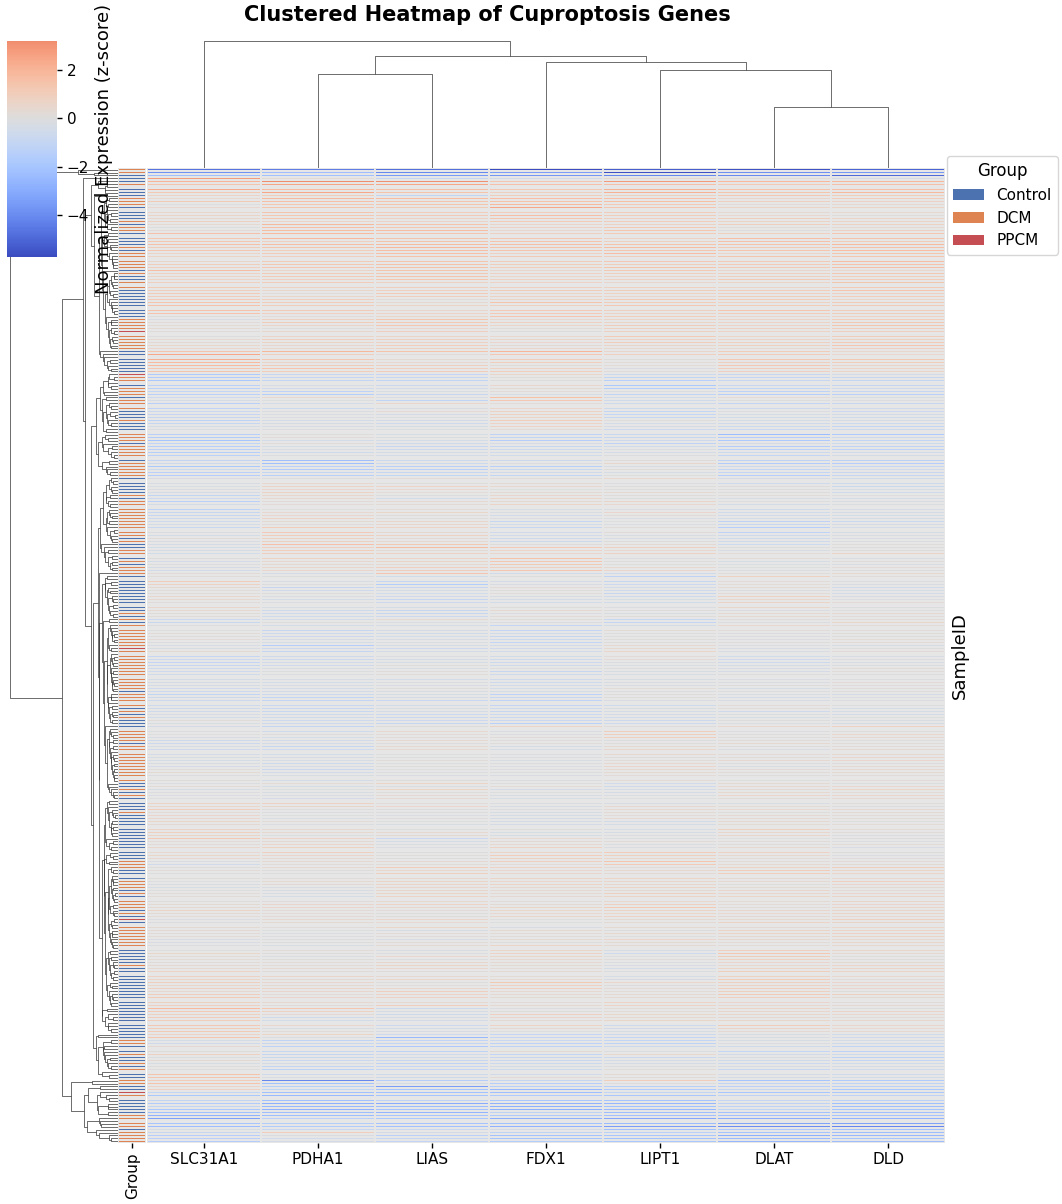

In [26]:
heatmap_data = X_scaled_df[available_cupro + ['Group']].copy()
row_colors = heatmap_data['Group'].map(PALETTE)
heatmap_matrix = heatmap_data[available_cupro]

g = sns.clustermap(
    heatmap_matrix,
    cmap='coolwarm', center=0,
    row_colors=row_colors,
    col_cluster=True, row_cluster=True,
    figsize=(10, 12),
    dendrogram_ratio=(0.12, 0.12),
    cbar_kws={'label': 'Normalized Expression (z-score)'},
    linewidths=0.3, linecolor='0.9',
    yticklabels=False,
    xticklabels=True,
)
g.fig.suptitle('Clustered Heatmap of Cuproptosis Genes', y=1.01, fontweight='bold')

# Legend for group colors
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=PALETTE[g], label=g) for g in GROUP_ORDER if g in set(y_str)]
g.ax_heatmap.legend(handles=legend_handles, title='Group', bbox_to_anchor=(1.15, 1.02), frameon=True)

save_fig('Figure4_Clustermap')
plt.show()

### Figure 5 — Spearman Correlation Matrix

Spearman rank correlation assesses monotonic co-expression relationships among cuproptosis genes,
identifying coordinated transcriptional modules that may reflect shared regulatory pathways.

  Saved → figures/Figure5_Correlation_Matrix.pdf


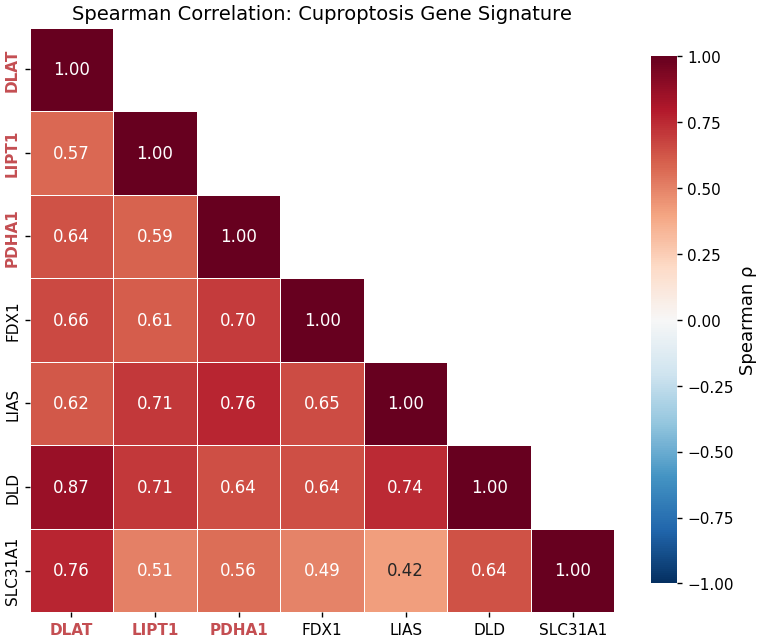

In [27]:
corr_matrix = heatmap_matrix.corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 7))
mask_upper = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix, mask=mask_upper, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Spearman ρ', 'shrink': 0.8},
    ax=ax
)

# Bold highlight genes on axes
for tick in ax.get_xticklabels():
    if tick.get_text() in HIGHLIGHT_GENES:
        tick.set_fontweight('bold')
        tick.set_color('#C44E52')
for tick in ax.get_yticklabels():
    if tick.get_text() in HIGHLIGHT_GENES:
        tick.set_fontweight('bold')
        tick.set_color('#C44E52')

ax.set_title('Spearman Correlation: Cuproptosis Gene Signature')
plt.tight_layout()
save_fig('Figure5_Correlation_Matrix')
plt.show()

## 3. Baseline Machine Learning Models

**Rationale:** Before deploying a Transformer architecture, we benchmark three established classifiers
on SMOTE-balanced cuproptosis features: LASSO logistic regression (sparse linear model), SVM with
RBF kernel (non-linear margin classifier), and Random Forest (ensemble of decision trees).
An 80/20 stratified split preserves class proportions in the test set.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=RANDOM_STATE, stratify=y_bal
)

models = {
    'LASSO': LogisticRegression(
        penalty='l1', solver='saga', C=1.0, max_iter=5000,
        multi_class='multinomial', random_state=RANDOM_STATE
    ),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

baseline_results = {}
trained_models = {}

print('=' * 70)
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    trained_models[name] = model

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    baseline_results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

    print(f'\n{name}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1-Score : {f1:.4f}')
    print(classification_report(y_test, y_pred, target_names=le.classes_))
print('=' * 70)


LASSO
  Accuracy : 0.7500
  Precision: 0.7496
  Recall   : 0.7500
  F1-Score : 0.7494
              precision    recall  f1-score   support

     Control       0.94      0.94      0.94        33
         DCM       0.65      0.61      0.62        33
        PPCM       0.67      0.71      0.69        34

    accuracy                           0.75       100
   macro avg       0.75      0.75      0.75       100
weighted avg       0.75      0.75      0.75       100


SVM (RBF)
  Accuracy : 0.8000
  Precision: 0.8112
  Recall   : 0.8000
  F1-Score : 0.7990
              precision    recall  f1-score   support

     Control       0.97      0.85      0.90        33
         DCM       0.75      0.64      0.69        33
        PPCM       0.72      0.91      0.81        34

    accuracy                           0.80       100
   macro avg       0.81      0.80      0.80       100
weighted avg       0.81      0.80      0.80       100


Random Forest
  Accuracy : 0.8300
  Precision: 0.8326
  Rec

### Figure 6 — Random Forest Feature Importance

Gini-based feature importances identify which cuproptosis genes contribute most to
discriminating PPCM from Control and DCM in the ensemble model.

  Saved → figures/Figure6_Feature_Importance.pdf


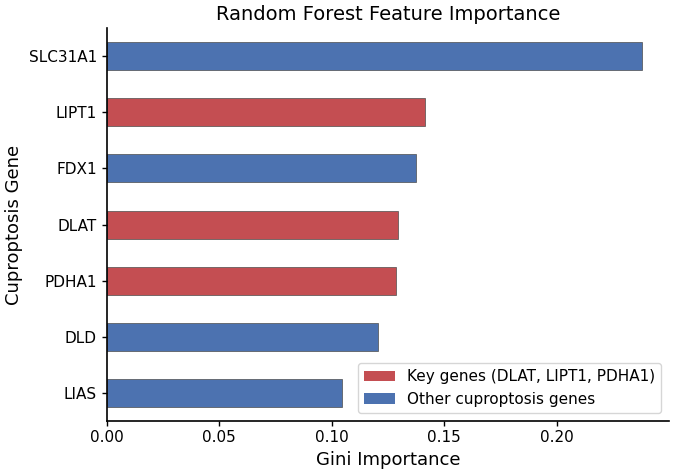

In [29]:
rf_model = trained_models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=available_cupro).sort_values()

colors = ['#C44E52' if g in HIGHLIGHT_GENES else '#4C72B0' for g in importances.index]

fig, ax = plt.subplots(figsize=(7, 5))
importances.plot.barh(ax=ax, color=colors, edgecolor='0.3', linewidth=0.5)
ax.set_xlabel('Gini Importance')
ax.set_ylabel('Cuproptosis Gene')
ax.set_title('Random Forest Feature Importance')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#C44E52', label='Key genes (DLAT, LIPT1, PDHA1)'),
    Patch(facecolor='#4C72B0', label='Other cuproptosis genes'),
], loc='lower right', frameon=True, edgecolor='0.8')

plt.tight_layout()
save_fig('Figure6_Feature_Importance')
plt.show()

## 4. Transcriptome-Transformer Deep Learning Model (PyTorch)

**Architecture rationale:** Tabular gene expression is treated as a sequence of tokenized features.
Each gene is linearly embedded into a 128-dimensional space with learned positional encodings.
A 3-layer Transformer encoder (4 attention heads) captures inter-gene dependencies via self-attention,
followed by global average pooling and an MLP classification head with dropout regularization.

In [30]:
class TranscriptomeTransformer(nn.Module):
    """
    Tabular Transformer for multi-class cardiomyopathy classification.

    Input:  (batch, n_genes)  — scaled cuproptosis expression vector
    Output: (batch, n_classes) — logits for Control / DCM / PPCM
    """
    def __init__(self, n_genes: int, n_classes: int = 3,
                 d_model: int = 128, nhead: int = 4,
                 num_layers: int = 3, dropout: float = 0.2):
        super().__init__()
        self.d_model = d_model

        # Project each scalar gene value to d_model via per-gene linear embedding
        self.gene_embedding = nn.Linear(1, d_model)

        # Learnable positional / feature encoding (one vector per gene position)
        self.pos_encoding = nn.Parameter(torch.randn(1, n_genes, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True,
            activation='gelu'
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, n_classes),
        )

    def forward(self, x):
        # x: (batch, n_genes) → (batch, n_genes, 1)
        x = x.unsqueeze(-1)
        # Embed: (batch, n_genes, d_model)
        x = self.gene_embedding(x) + self.pos_encoding
        # Transformer encoding
        x = self.transformer_encoder(x)
        # Global average pooling over gene dimension
        x = x.mean(dim=1)
        return self.classifier(x)


n_genes = X_train.shape[1]
n_classes = len(le.classes_)
transformer = TranscriptomeTransformer(n_genes=n_genes, n_classes=n_classes).to(device)
print(transformer)
print(f'\nTotal parameters: {sum(p.numel() for p in transformer.parameters()):,}')

TranscriptomeTransformer(
  (gene_embedding): Linear(in_features=1, out_features=128, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (1): Dropout(p=0.2, inplace=False)
    (2): Linear(in_features=128, out_features=64, bias=T

In [31]:
# ── Training loop (100 epochs, AdamW + cosine LR scheduler) ───────────────────
EPOCHS = 100
BATCH_SIZE = 32
LR = 1e-3

# Further split training into train/val for monitoring
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=RANDOM_STATE, stratify=y_train
)

def make_loader(X, y, shuffle=False):
    ds = TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = make_loader(X_tr, y_tr, shuffle=True)
val_loader   = make_loader(X_val, y_val)
test_loader  = make_loader(X_test, y_test)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(transformer.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

train_losses, val_losses = [], []
best_val_loss = float('inf')
best_state = None

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    transformer.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = transformer(xb)
        loss = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(transformer.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # ── Validate ──
    transformer.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += criterion(transformer(xb), yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)
    scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in transformer.state_dict().items()}

    if epoch % 20 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f}')

# Restore best model
transformer.load_state_dict(best_state)
transformer.eval()
print(f'\nBest validation loss: {best_val_loss:.4f}')

Epoch   1/100 | Train Loss: 1.1231 | Val Loss: 1.0099
Epoch  20/100 | Train Loss: 0.7856 | Val Loss: 0.7685
Epoch  40/100 | Train Loss: 0.6448 | Val Loss: 0.6518
Epoch  60/100 | Train Loss: 0.5477 | Val Loss: 0.5285
Epoch  80/100 | Train Loss: 0.4538 | Val Loss: 0.4967
Epoch 100/100 | Train Loss: 0.4420 | Val Loss: 0.4834

Best validation loss: 0.4584


### Figure 7 — Training and Validation Loss Curves

Convergence of training and validation loss over 100 epochs demonstrates that the Transformer
learns discriminative cuproptosis representations without severe overfitting.

  Saved → figures/Figure7_Loss_Curves.pdf


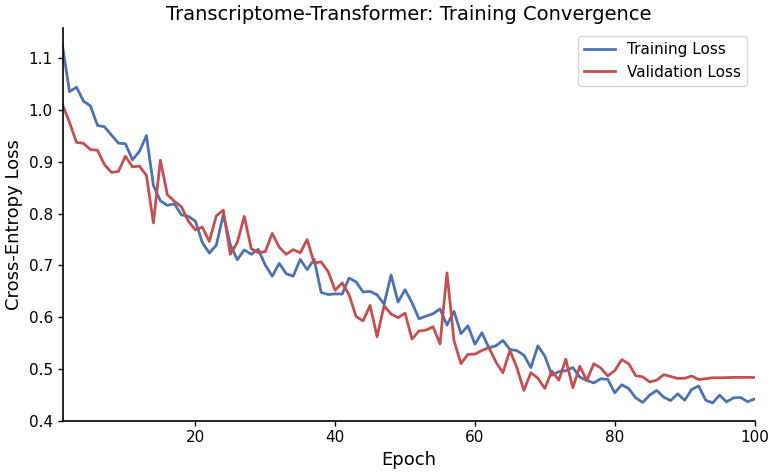

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
epochs_range = range(1, EPOCHS + 1)
ax.plot(epochs_range, train_losses, color='#4C72B0', lw=2, label='Training Loss')
ax.plot(epochs_range, val_losses, color='#C44E52', lw=2, label='Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Transcriptome-Transformer: Training Convergence')
ax.legend(frameon=True, edgecolor='0.8')
ax.set_xlim(1, EPOCHS)
plt.tight_layout()
save_fig('Figure7_Loss_Curves')
plt.show()

## 5. Final Evaluation

### Transformer Classification Report

In [33]:
with torch.no_grad():
    X_test_t = torch.FloatTensor(X_test).to(device)
    transformer_logits = transformer(X_test_t).cpu().numpy()
    transformer_probs = torch.softmax(torch.FloatTensor(transformer_logits), dim=1).numpy()
    transformer_preds = transformer_probs.argmax(axis=1)

print('Transcriptome-Transformer — Test Set Performance')
print(f'  Accuracy : {accuracy_score(y_test, transformer_preds):.4f}')
print(f'  Precision: {precision_score(y_test, transformer_preds, average="weighted", zero_division=0):.4f}')
print(f'  Recall   : {recall_score(y_test, transformer_preds, average="weighted", zero_division=0):.4f}')
print(f'  F1-Score : {f1_score(y_test, transformer_preds, average="weighted", zero_division=0):.4f}')
print(classification_report(y_test, transformer_preds, target_names=le.classes_))

Transcriptome-Transformer — Test Set Performance
  Accuracy : 0.7900
  Precision: 0.7903
  Recall   : 0.7900
  F1-Score : 0.7861
              precision    recall  f1-score   support

     Control       0.87      0.79      0.83        33
         DCM       0.72      0.64      0.68        33
        PPCM       0.78      0.94      0.85        34

    accuracy                           0.79       100
   macro avg       0.79      0.79      0.79       100
weighted avg       0.79      0.79      0.79       100



### Figure 8 — Multi-class ROC Curves (One-vs-Rest, PPCM Class)

ROC curves compare the ability of the Transformer, Random Forest, and SVM to distinguish
PPCM patients from all other classes. AUC values quantify discriminative performance.

  Saved → figures/Figure8_ROC_Curves.pdf


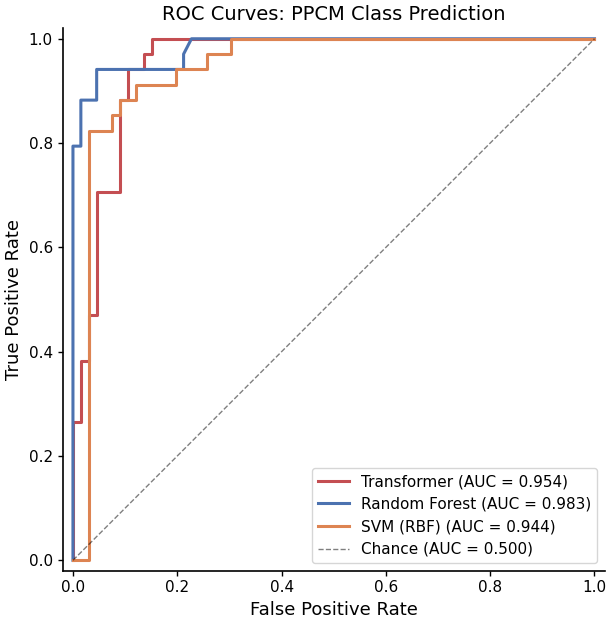

In [34]:
ppcm_idx = list(le.classes_).index('PPCM')

def get_ppcm_probs(model_name, model):
    if model_name == 'Transformer':
        return transformer_probs[:, ppcm_idx]
    return model.predict_proba(X_test)[:, ppcm_idx]

y_binary = (y_test == ppcm_idx).astype(int)

roc_models = {
    'Transformer': ('#C44E52', transformer),
    'Random Forest': ('#4C72B0', trained_models['Random Forest']),
    'SVM (RBF)': ('#DD8452', trained_models['SVM (RBF)']),
}

fig, ax = plt.subplots(figsize=(7, 6.5))

for name, (color, model) in roc_models.items():
    y_score = get_ppcm_probs(name, model)
    fpr, tpr, _ = roc_curve(y_binary, y_score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.2, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Chance (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves: PPCM Class Prediction')
ax.legend(loc='lower right', frameon=True, edgecolor='0.8')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect('equal')
plt.tight_layout()
save_fig('Figure8_ROC_Curves')
plt.show()

## Summary

| Figure | File | Description |
|--------|------|-------------|
| 1 | `figures/Figure1_PCA.pdf` | PCA of global gene expression |
| 2 | `figures/Figure2_Volcano.pdf` | Volcano plot: PPCM vs. Control |
| 3 | `figures/Figure3_Violin_Boxplots.pdf` | DLAT, LIPT1, PDHA1 expression with significance |
| 4 | `figures/Figure4_Clustermap.pdf` | Hierarchical clustered heatmap |
| 5 | `figures/Figure5_Correlation_Matrix.pdf` | Spearman correlation matrix |
| 6 | `figures/Figure6_Feature_Importance.pdf` | Random Forest feature importances |
| 7 | `figures/Figure7_Loss_Curves.pdf` | Transformer training/validation loss |
| 8 | `figures/Figure8_ROC_Curves.pdf` | ROC curves for PPCM prediction |

---

*All figures saved at 300 DPI in PDF format, ready for direct inclusion in LaTeX manuscripts via `\includegraphics{}`.*